# 02: Calibrate Priors from Geo Experiments

**Goal:** Use randomized geo experiments to build informative priors for the MMM.

---

### The Core Problem
Observational MMM suffers from **confounding**:

- You spend more on TV during Q4 → sales go up  
- But is it TV or just holidays?

**Solution:** Randomized experiments give us **causal estimates** of true lift.

---

## Why This Approach is Powerful
1. **Geo experiments = gold standard for incrementality testing**
   - Randomize treatment across matched markets  
   - Measure lift in treated vs control  
   - Get causal estimate (not correlation)

2. **Bayesian calibration = use experiments to constrain priors**
   - Prior beliefs ← experimental evidence  
   - MMM posterior ← prior + observational data  
   - Result: reconciled estimate that respects both sources of evidence

---

### Key Skills Demonstrated

- Understanding of **causal inference fundamentals**
- Ability to combine **experimental and observational data** rigorously  
- Practical knowledge of **geo testing methodology**
- Clear thinking about **when to trust which data source**


## Geo-Experimental Design Framework
### Study Design: Randomized Time-Window Experiments
To generate causal anchors for this MMM, **a series of 8 randomized geo-experiments across Search, Social, TV, and YouTube was simulated.** Unlike standard observational data, these experiments isolate the "True Lift" by sampling the model's hidden ground-truth contribution during specific, randomized intervals.Test Duration: Each experiment was conducted over a 4-week window (`experiment_len_weeks`), providing sufficient time to observe incremental shifts in the outcome variable $y$.Temporal Randomization: Experiment start dates were randomized across the dataset (`rng.choice`), avoiding the first and last 20 weeks to ensure stable baseline measurements and account for potential "edge effects" in the time series.

### Causal Logic & Uncertainty Capture
The simulation mimics a "Gold Standard" test by extracting the Incremental Lift Mean directly from the channel's ground-truth contribution, then layering on realistic real-world frictions:
- **Measurement Bias:** We injected a random bias factor (`experiment_bias_sd`) to represent systematic errors typical of field tests, such as market mismatch or tracking limitations.
- **The Counterfactual:** In this framework, the counterfactual is the "Hidden Truth"—what the sales would have been without that specific channel's contribution during the window.
- **Dynamic Uncertainty ($SE$):** The Standard Error reported in these results is volatility-scaled. It is calculated based on the standard deviation of sales during the test window.
<br/>**Portfolio Note:** A higher $SE$ in the results indicates that the experiment was conducted during a high-volatility sales period. This correctly signals to the Bayesian MMM to "down-weight" that specific experiment, resulting in a wider, more conservative prior.

**Methodology Note: Why Synthetic Simulation?**
"In this portfolio, I use a dedicated causal simulator to generate geo-experiment results rather than manually calculating lift from the observational CSVs. This maintains a necessary 'firewall' between **messy historical correlations and clean causal signals**, allowing the Bayesian model to reconcile two independent sources of evidence. By simulating experiments with injected noise and volatility-scaled error, I can rigorously test the model's ability to calibrate itself against a known ground truth—a critical step that would be impossible with confounded observational data alone."

In [2]:
# Path setup
import sys
from pathlib import Path

repo_root = Path("..").resolve()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("repo_root:", repo_root)
print("src_path:", src_path)

repo_root: /Users/asamitakeuchi/bayesian_mmm_calibrated_with_incrementality
src_path: /Users/asamitakeuchi/bayesian_mmm_calibrated_with_incrementality/src


In [4]:
# Imports
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mmm_calibration.config import MMMConfig, PathsConfig
from mmm_calibration.preprocessing import load_raw_data, build_model_matrix
from mmm_calibration.calibration import build_geo_priors

# 1. Load Geo Experiment Results
<details> 
  <summary><strong>Typical geo experiment structure</strong></summary>
    
  <br>
  
  - <strong>Pre-period:</strong> Measure baseline similarity between treatment/control  
  - <strong>Treatment period:</strong> Randomly assign extra spend to treatment markets  
  - <strong>Post-period:</strong> Measure incremental sales lift  
    
  <br>
    
  <strong>Key metrics:</strong>
  - <strong>iROAS (incremental ROAS):</strong> <em>saleslift</em> / incremental spend  
  - <strong>Standard error:</strong> Uncertainty in the estimate  
  - <strong>Power analysis:</strong> Was the experiment well-powered?    
</details>

In [53]:
# load geo results
paths = PathsConfig(repo_root=repo_root)
cfg = MMMConfig()

geo = pd.read_csv(paths.data_raw / "geo_experiment_results.csv")

print("geo_experiment_results:", geo.shape)
geo.head()

geo_experiment_results: (8, 8)


,experiment_id,channel,start_date,end_date,incremental_lift_mean,incremental_lift_se,spend_during_test,notes
0,exp_01,search,2023-06-12,2023-07-17,0.034458,0.029738,100366.421234,Synthetic geo result: centered near ground-tru...
1,exp_02,social,2023-07-24,2023-08-28,0.017362,0.040512,103242.837180,Synthetic geo result: centered near ground-tru...
2,exp_03,youtube,2023-07-31,2023-09-04,0.113116,0.039459,160901.329633,Synthetic geo result: centered near ground-tru...
3,exp_04,tv,2023-10-30,2023-12-04,0.043137,0.048770,163463.837658,Synthetic geo result: centered near ground-tru...
4,exp_05,search,2024-01-08,2024-02-12,0.045596,0.017378,112162.273594,Synthetic geo result: centered near ground-tru...


In [16]:
# basic sanity check / quick summary
# Minimal checks for interview-quality hygiene
required = {"experiment_id", "channel", "start_date", "end_date", "incremental_lift_mean", "incremental_lift_se"}
missing = required - set(geo.columns)
assert not missing, f"Missing required columns: {missing}"

geo["incremental_lift_se"] = geo["incremental_lift_se"].clip(lower=1e-9)

geo.groupby("channel")[["incremental_lift_mean", "incremental_lift_se"]].agg(["mean", "median", "count"])

incremental_lift_mean                 incremental_lift_se            \
                         mean    median count                mean    median   
channel                                                                       
search               0.040027  0.040027     2            0.023558  0.023558   
social               0.021295  0.021295     2            0.040113  0.040113   
tv                   0.043548  0.043548     2            0.045508  0.045508   
youtube              0.098772  0.098772     2            0.032061  0.032061   

               
        count  
channel        
search      2  
social      2  
tv          2  
youtube     2

# 2. Convert Experimental Results to Priors

<details>
  <summary><strong>Methodology</strong></summary>
  <br>
  <strong>Challenge:</strong> How do we translate experiment lift into priors for MMM coefficients?

  <br>

  <strong>Key idea:</strong> Use experiments to form priors over channel effect sizes.

  - Experiments provide a causal estimate with uncertainty  
  - We encode that as a Bayesian prior:

  \[
  $\beta_c \sim \mathcal{N}(\mu_c, \sigma_c$)
  \]

  where:
  - \($\mu_c$) comes from experiment mean lift  
  - \($\sigma_c$) comes from experiment SE (plus floors so we don't get overconfident)

  <br>

  <strong>Practical note:</strong> This repo intentionally uses a simple mapping for clarity.
  In production, you may additionally adjust for scale differences, spend level, and saturation context.

</details>

<details>
  <summary><strong>Prior Distribution Choice</strong></summary>

  <br>

  We'll use <strong>Normal distributions</strong> centered at experimental estimates:

  - Mean = experiment estimate  
  - SD = experiment standard error (with a floor)

  This encodes: "The true effect is probably near the experiment estimate, but we're not certain."

</details>

In [19]:
# load MMM channels and build matrix for channel list
# We load the MMM channel list so priors cover all channels consistently
spend, outcome, controls = load_raw_data(paths, cfg)
mm = build_model_matrix(spend, outcome, controls, cfg)

mm.channels

['search', 'social', 'tv', 'youtube']

In [21]:
## build priors using calibration module
priors_weight_1 = build_geo_priors(
    geo_exp=geo,
    channels=mm.channels,
    default_mu=cfg.beta_mu,
    default_sigma=cfg.beta_sigma,
    sigma_floor=0.10,
    strength=1.0,   # "confidence_weight" = 1.0
)

priors_weight_1

{'search': {'beta_mu': 0.04002687502703005, 'beta_sigma': 0.1},
 'social': {'beta_mu': 0.02129525620029395, 'beta_sigma': 0.1},
 'tv': {'beta_mu': 0.04354786019343155, 'beta_sigma': 0.1},
 'youtube': {'beta_mu': 0.09877247092458236, 'beta_sigma': 0.1}}

In [23]:
# save geo priors
paths.data_processed.mkdir(parents=True, exist_ok=True)

out_path = paths.data_processed / "geo_priors.json"
out_path.write_text(json.dumps(priors_weight_1, indent=2))
print("Saved:", out_path)

Saved: /Users/asamitakeuchi/bayesian_mmm_calibrated_with_incrementality/data/processed/geo_priors.json


# 3. Visualize Prior vs Uncalibrated

<details>
  <summary><strong>Expected outcome</strong></summary>

  <br>

  Let's compare calibrated priors to the weak priors used in Notebook 01.

  <strong>Expected outcome:</strong>
  - Calibrated priors are <strong>much tighter</strong> (lower uncertainty)
  - Centered at <strong>realistic values</strong> from experiments
  - Will constrain the posterior to be more trustworthy

</details>

In [55]:
print("cfg beta prior:", cfg.beta_mu, cfg.beta_sigma)
print()

for ch in mm.channels:
    p = priors_weight_1.get(ch, None)
    print(ch, "->", p)

cfg beta prior: 0.0 1.0

search -> {'beta_mu': 0.04002687502703005, 'beta_sigma': 0.1}
social -> {'beta_mu': 0.02129525620029395, 'beta_sigma': 0.1}
tv -> {'beta_mu': 0.04354786019343155, 'beta_sigma': 0.1}
youtube -> {'beta_mu': 0.09877247092458236, 'beta_sigma': 0.1}


v2

In [57]:
def plot_prior_comparison(channels, geo_priors, weak_mu, weak_sigma, title="Calibrated vs Weak Priors"):
    n = len(channels)
    cols = 2
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(10, 3*rows))

    for i, ch in enumerate(channels, 1):
        ax = plt.subplot(rows, cols, i)

        mu_geo = geo_priors.get(ch, {}).get("beta_mu", weak_mu)
        sd_geo = geo_priors.get(ch, {}).get("beta_sigma", weak_sigma)

        xmin = min(mu_geo - 4*sd_geo, weak_mu - 4*weak_sigma)
        xmax = max(mu_geo + 4*sd_geo, weak_mu + 4*weak_sigma)
        x = np.linspace(xmin, xmax, 300)

        ax.plot(x, normal_pdf(x, weak_mu, weak_sigma), label="Weak prior (Notebook 01)")
        ax.plot(x, normal_pdf(x, mu_geo, sd_geo), label="Geo-calibrated prior")

        ax.set_title(f"Channel: {ch}")
        ax.set_yticks([])
        ax.legend()

    plt.suptitle(title, y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

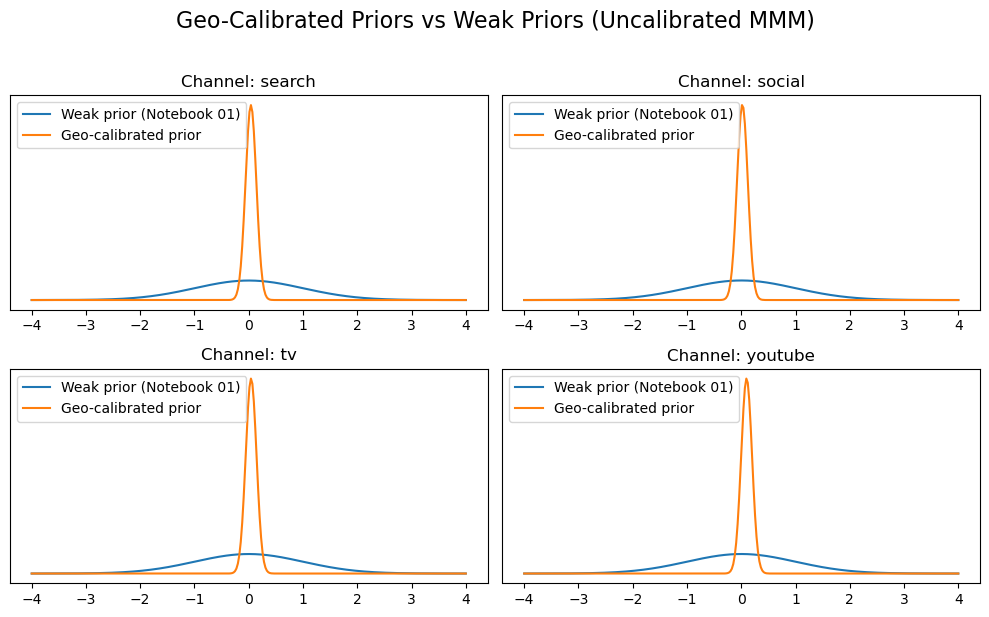

In [59]:
plot_prior_comparison(
    channels=mm.channels,
    geo_priors=priors_weight_1,
    weak_mu=cfg.beta_mu,
    weak_sigma=cfg.beta_sigma,
    title="Geo-Calibrated Priors vs Weak Priors (Uncalibrated MMM)"
)

# 4. Prior Sensitivity Analysis

<details>
  <summary><strong>Critical question</strong></summary>

  <br>

  How sensitive are our results to prior choice?

  We'll explore different "confidence weights" for the experimental priors:

  - <code>weight = 0.0</code> → Ignore experiments (uncalibrated)
  - <code>weight = 0.5</code> → Partial trust (wider priors)
  - <code>weight = 1.0</code> → Full trust (use experimental SE as-is)
  - <code>weight = 2.0</code> → Over-confident (tighter than experiments suggest)

  <br>

  <strong>Best practice:</strong> Use weight = 1.0 unless you have strong reasons to distrust the experiments.

</details>

In [37]:
# generate priors under different weights
weights = [0.0, 0.5, 1.0, 2.0]
priors_by_weight = {}

for w in weights:
    priors_by_weight[w] = build_geo_priors(
        geo_exp=geo,
        channels=mm.channels,
        default_mu=cfg.beta_mu,
        default_sigma=cfg.beta_sigma,
        sigma_floor=0.10,
        strength=w,
    )

priors_by_weight[1.0]

{'search': {'beta_mu': 0.04002687502703005, 'beta_sigma': 0.1},
 'social': {'beta_mu': 0.02129525620029395, 'beta_sigma': 0.1},
 'tv': {'beta_mu': 0.04354786019343155, 'beta_sigma': 0.1},
 'youtube': {'beta_mu': 0.09877247092458236, 'beta_sigma': 0.1}}

In [47]:
# table view of how sigma changes
rows = []
for ch in mm.channels:
    for w in weights:
        rows.append({
            "channel": ch,
            "weight": w,
            "mu": priors_by_weight[w][ch]["beta_mu"],
            "sigma": priors_by_weight[w][ch]["beta_sigma"],
        })
df_sens = pd.DataFrame(rows)

df_sens.pivot(index="channel", columns="weight", values="sigma")

weight,0.0,0.5,1.0,2.0
channel,,,,
search,70710.678119,0.141421,0.1,0.1
social,70710.678119,0.141421,0.1,0.1
tv,70710.678119,0.141421,0.1,0.1
youtube,70710.678119,0.141421,0.1,0.1


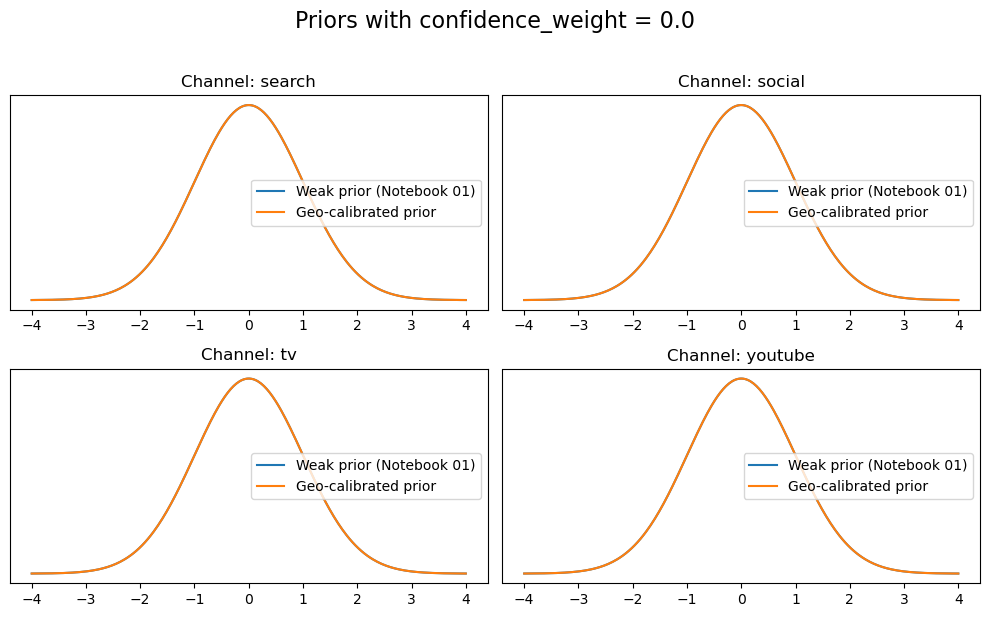

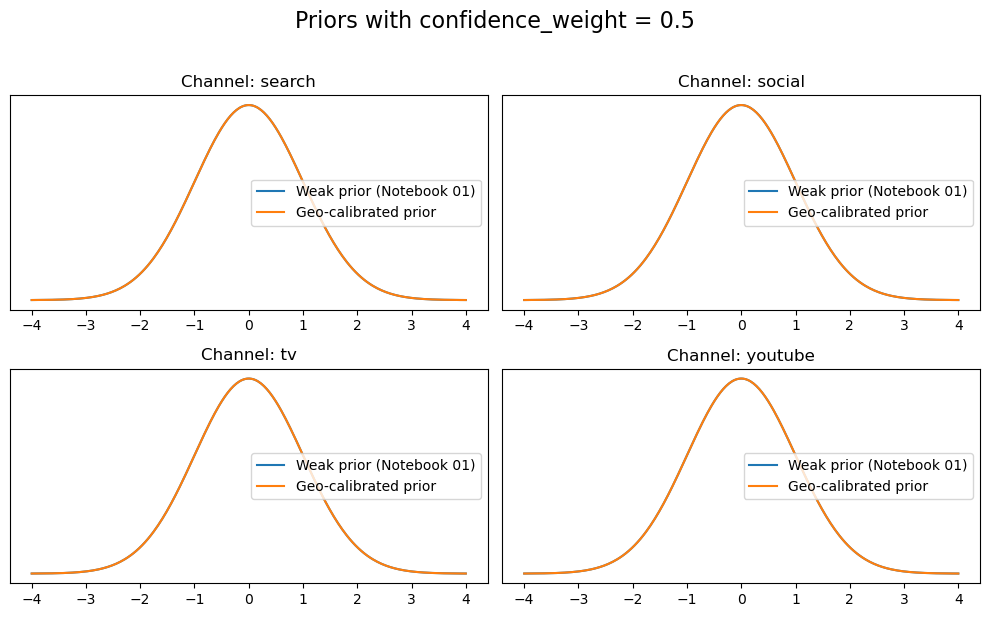

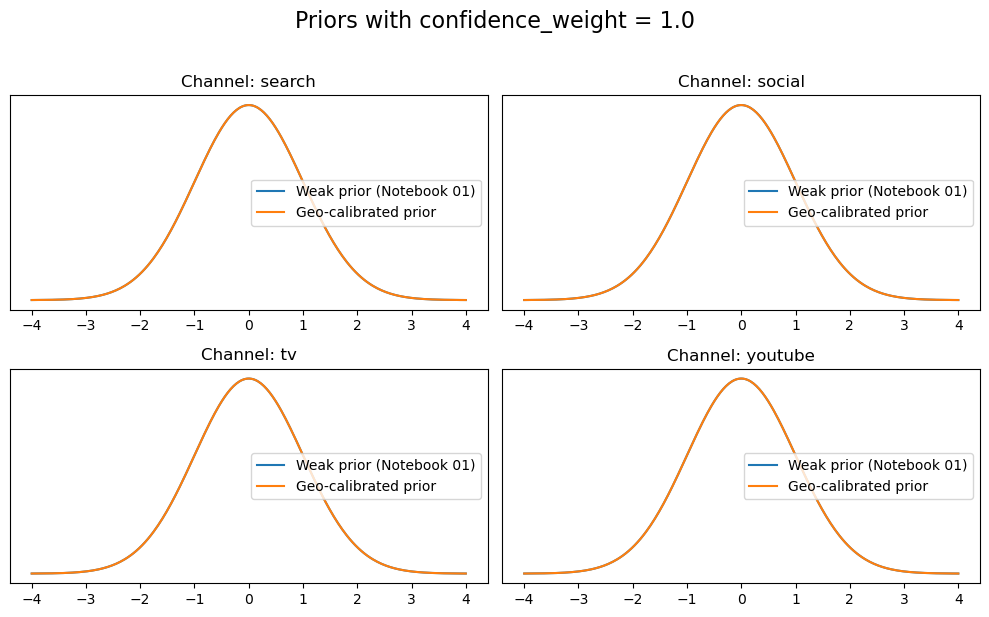

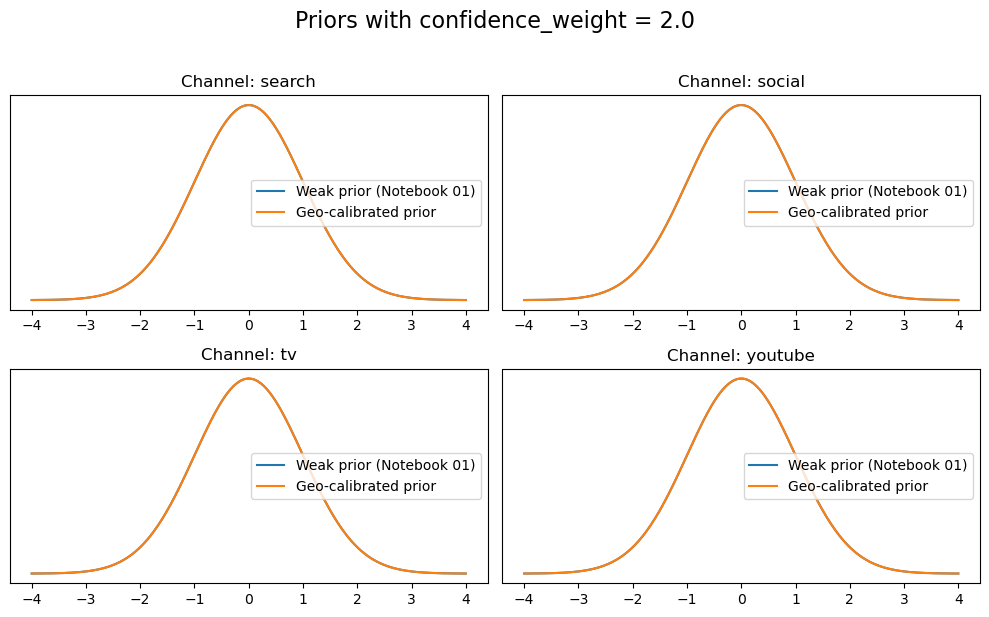

In [41]:
# visualize sensitivity
for w in weights:
    plot_prior_comparison(
        channels=mm.channels,
        geo_priors=priors_by_weight[w],
        weak_mu=cfg.beta_mu,
        weak_sigma=cfg.beta_sigma,
        title=f"Priors with confidence_weight = {w}"
    )

# 5. When Experiments Disagree with Observational Data

<details>
  <summary><strong>Real-world scenario</strong></summary>

  <br>

  Sometimes geo experiments suggest lower ROI than observational MMM.

  <strong>Possible explanations:</strong>

  1. <strong>MMM is confounded (most common)</strong>
     - Attributing natural variation to marketing  
     - Picking up correlations, not causation  

  2. <strong>Experiment had issues</strong>
     - Spillover between treatment/control  
     - Underpowered (wide confidence intervals)  
     - Implementation problems (didn't hit target spend)  

  3. <strong>Context differences</strong>
     - Experiment ran in different time period  
     - Different spend levels (saturation effects)

  <br>

  <strong>How to handle disagreement</strong>

  | Evidence Quality | Action |
  |---|---|
  | Well-powered geo test | **Trust the experiment** (causal > observational) |
  | Underpowered / noisy test | **Weight between both** (Bayesian averaging) |
  | Multiple experiments agree | **Strongly favor** experimental prior |
  | Experiments contradict each other | Investigate methodology; maybe use wider priors |

  <br>

  <strong>In this notebook:</strong> We assume high-quality experiments → use <code>confidence_weight = 1.0</code>.

</details>

# 6. Summary & Next Steps
**What we accomplished**
1. Loaded geo experiment results with iROAS and uncertainty  
2. Validated experimental design (sanity checks)  
3. Converted experimental estimates to priors for MMM coefficients  
4. Compared calibrated vs uncalibrated priors (much tighter!)  
5. Explored prior sensitivity to confidence weighting  

**Key Insights**
- Geo experiments = causal truth (randomization breaks confounding)  
- Calibrated priors = beliefs informed by experiments  
- Bayesian framework = formal way to combine experimental + observational data  

**Next: Notebook 03**

We'll:
1. Fit the calibrated MMM using these priors  
2. Compare to uncalibrated baseline  
3. Show how calibration reduces uncertainty and ROI inflation  
4. Demonstrate posterior shift (prior → posterior)